In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [6]:
from statsmodels.tsa.stattools import adfuller, kpss

In [7]:
import warnings

In [8]:
warnings.filterwarnings('ignore')

In [9]:
plt.rcParams['figure.figsize'] = (14, 5)

In [10]:
plt.rcParams['font.size'] = 12

In [11]:
print("All imports successful!")

All imports successful!


In [12]:
df = pd.read_csv('data/tea_demand_dataset.csv', parse_dates=['week_start_date'])
df = df.sort_values(['grade', 'week_start_date']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"\nDate range: {df['week_start_date'].min()} to {df['week_start_date'].max()}")
print(f"\nGrades: {df['grade'].unique()}")
print(f"\nColumns:\n{list(df.columns)}")
df.head()

Shape: (1040, 17)

Date range: 2021-01-04 00:00:00 to 2024-12-23 00:00:00

Grades: ['BOP' 'BOPF' 'Dust' 'OP' 'Pekoe']

Columns:
['week_start_date', 'year', 'month', 'week_of_year', 'grade', 'demand_kg', 'production_kg', 'inventory_kg', 'colombo_auction_price_lkr', 'auction_price_lag1w', 'auction_price_lag4w', 'rainfall_index', 'usd_lkr_rate', 'festival_flag', 'global_commodity_shock', 'demand_rolling4w_avg', 'demand_rolling12w_avg']


,week_start_date,year,month,week_of_year,grade,demand_kg,production_kg,inventory_kg,colombo_auction_price_lkr,auction_price_lag1w,auction_price_lag4w,rainfall_index,usd_lkr_rate,festival_flag,global_commodity_shock,demand_rolling4w_avg,demand_rolling12w_avg
0,2021-01-04,2021,1,1,BOP,3064,2712,0,1514.36,1500.32,1486.15,17.9,313.24,0,0.0199,NaN,NaN
1,2021-01-11,2021,1,2,BOP,2704,2629,136,1404.99,1396.53,1321.90,32.3,305.15,0,-0.0423,3064.0,3064.0
2,2021-01-18,2021,1,3,BOP,3013,2653,0,1518.83,1521.47,1500.66,35.1,314.30,0,-0.0029,2884.0,2884.0
3,2021-01-25,2021,1,4,BOP,3007,3017,502,1424.08,1421.96,1314.78,0.0,311.59,0,-0.0094,2927.0,2927.0
4,2021-02-01,2021,2,5,BOP,2966,3105,0,1519.31,1470.46,1530.53,31.1,310.25,0,-0.0425,2947.0,2947.0


In [13]:
print("Demand statistics per grade (kg/week):\n")
print(df.groupby('grade')['demand_kg'].describe().round(0))

Demand statistics per grade (kg/week):

       count    mean     std     min     25%     50%     75%      max
grade                                                                
BOP    208.0  3802.0   566.0  2123.0  3462.0  3846.0  4120.0   5335.0
BOPF   208.0  4477.0   790.0  2458.0  3836.0  4544.0  5045.0   6308.0
Dust   208.0  6278.0  1444.0  3026.0  5308.0  6058.0  7502.0  10431.0
OP     208.0  2279.0   317.0  1604.0  2038.0  2282.0  2528.0   3191.0
Pekoe  208.0  1512.0   230.0  1014.0  1371.0  1498.0  1671.0   2221.0


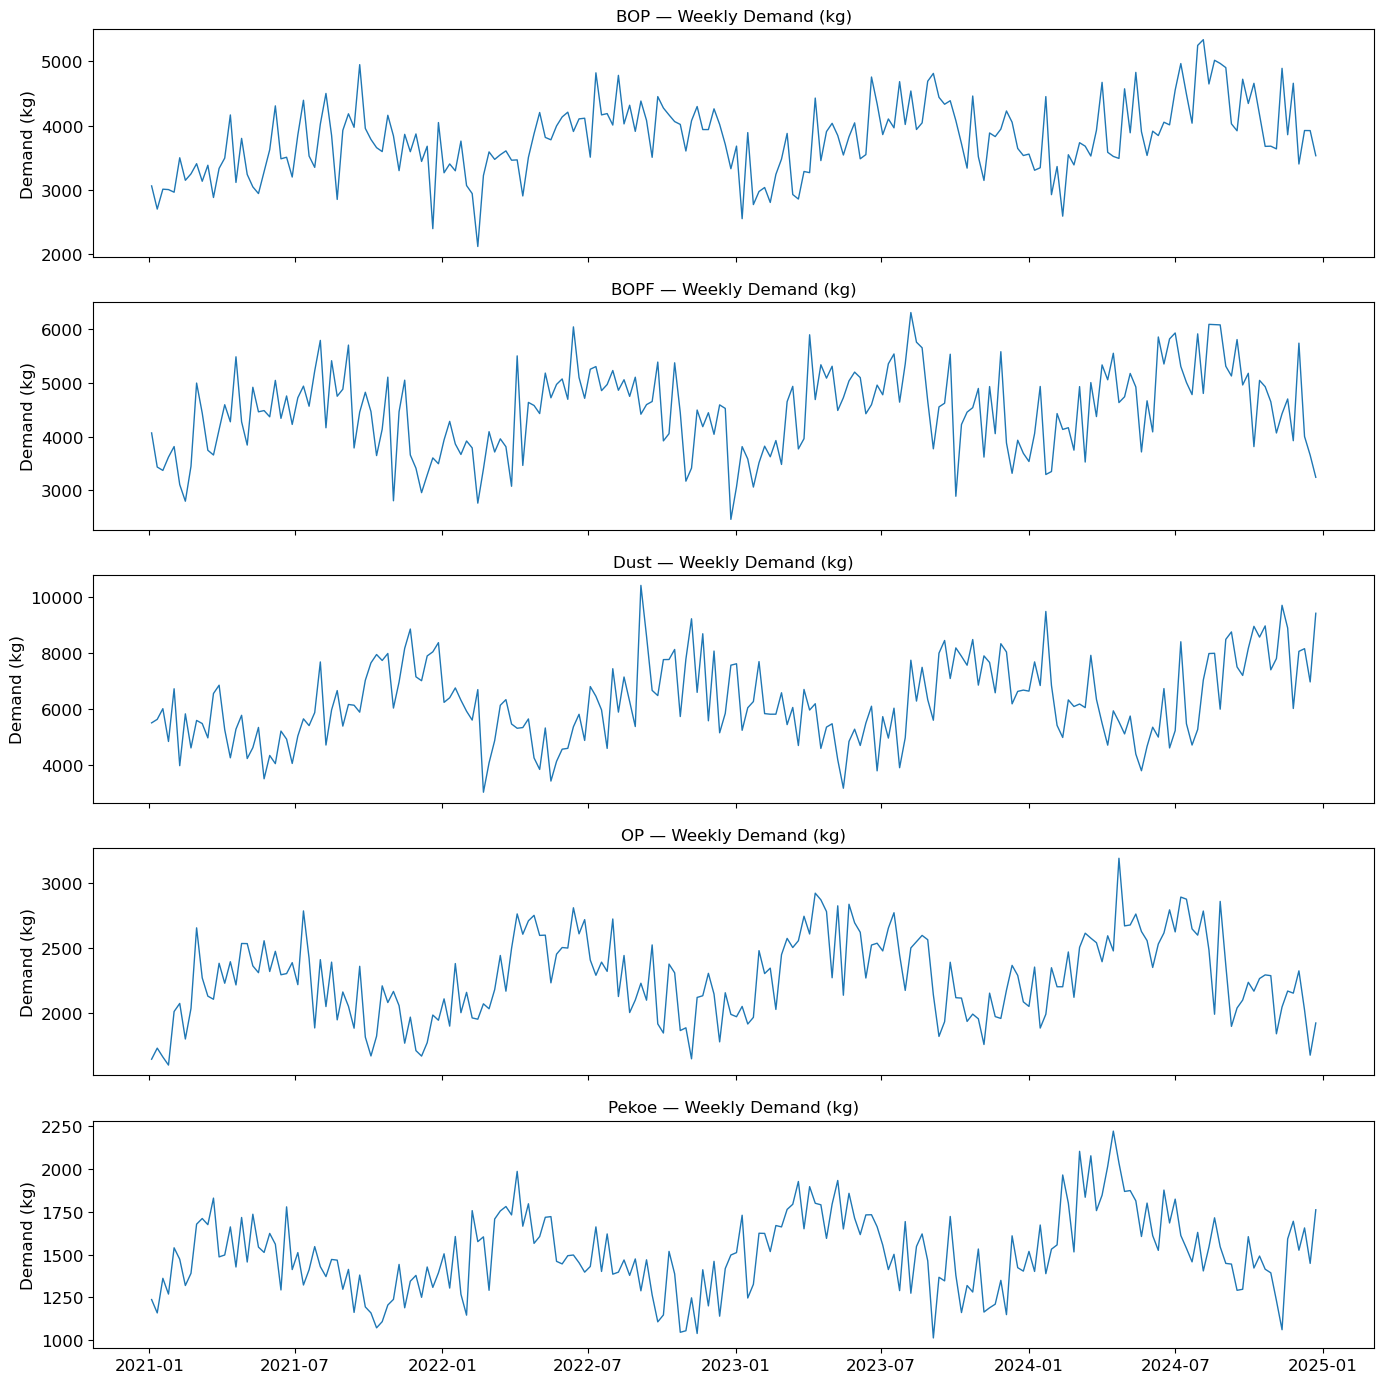

Plot saved to plots/demand_timeseries.png


In [14]:
import os
os.makedirs('plots', exist_ok=True)

grades = df['grade'].unique()
fig, axes = plt.subplots(len(grades), 1, figsize=(14, 14), sharex=True)

for ax, grade in zip(axes, grades):
    data = df[df['grade'] == grade]
    ax.plot(data['week_start_date'], data['demand_kg'], linewidth=1)
    ax.set_title(f'{grade} — Weekly Demand (kg)', fontsize=12)
    ax.set_ylabel('Demand (kg)')

plt.tight_layout()
plt.savefig('plots/demand_timeseries.png', dpi=150)
plt.show()
print("Plot saved to plots/demand_timeseries.png")

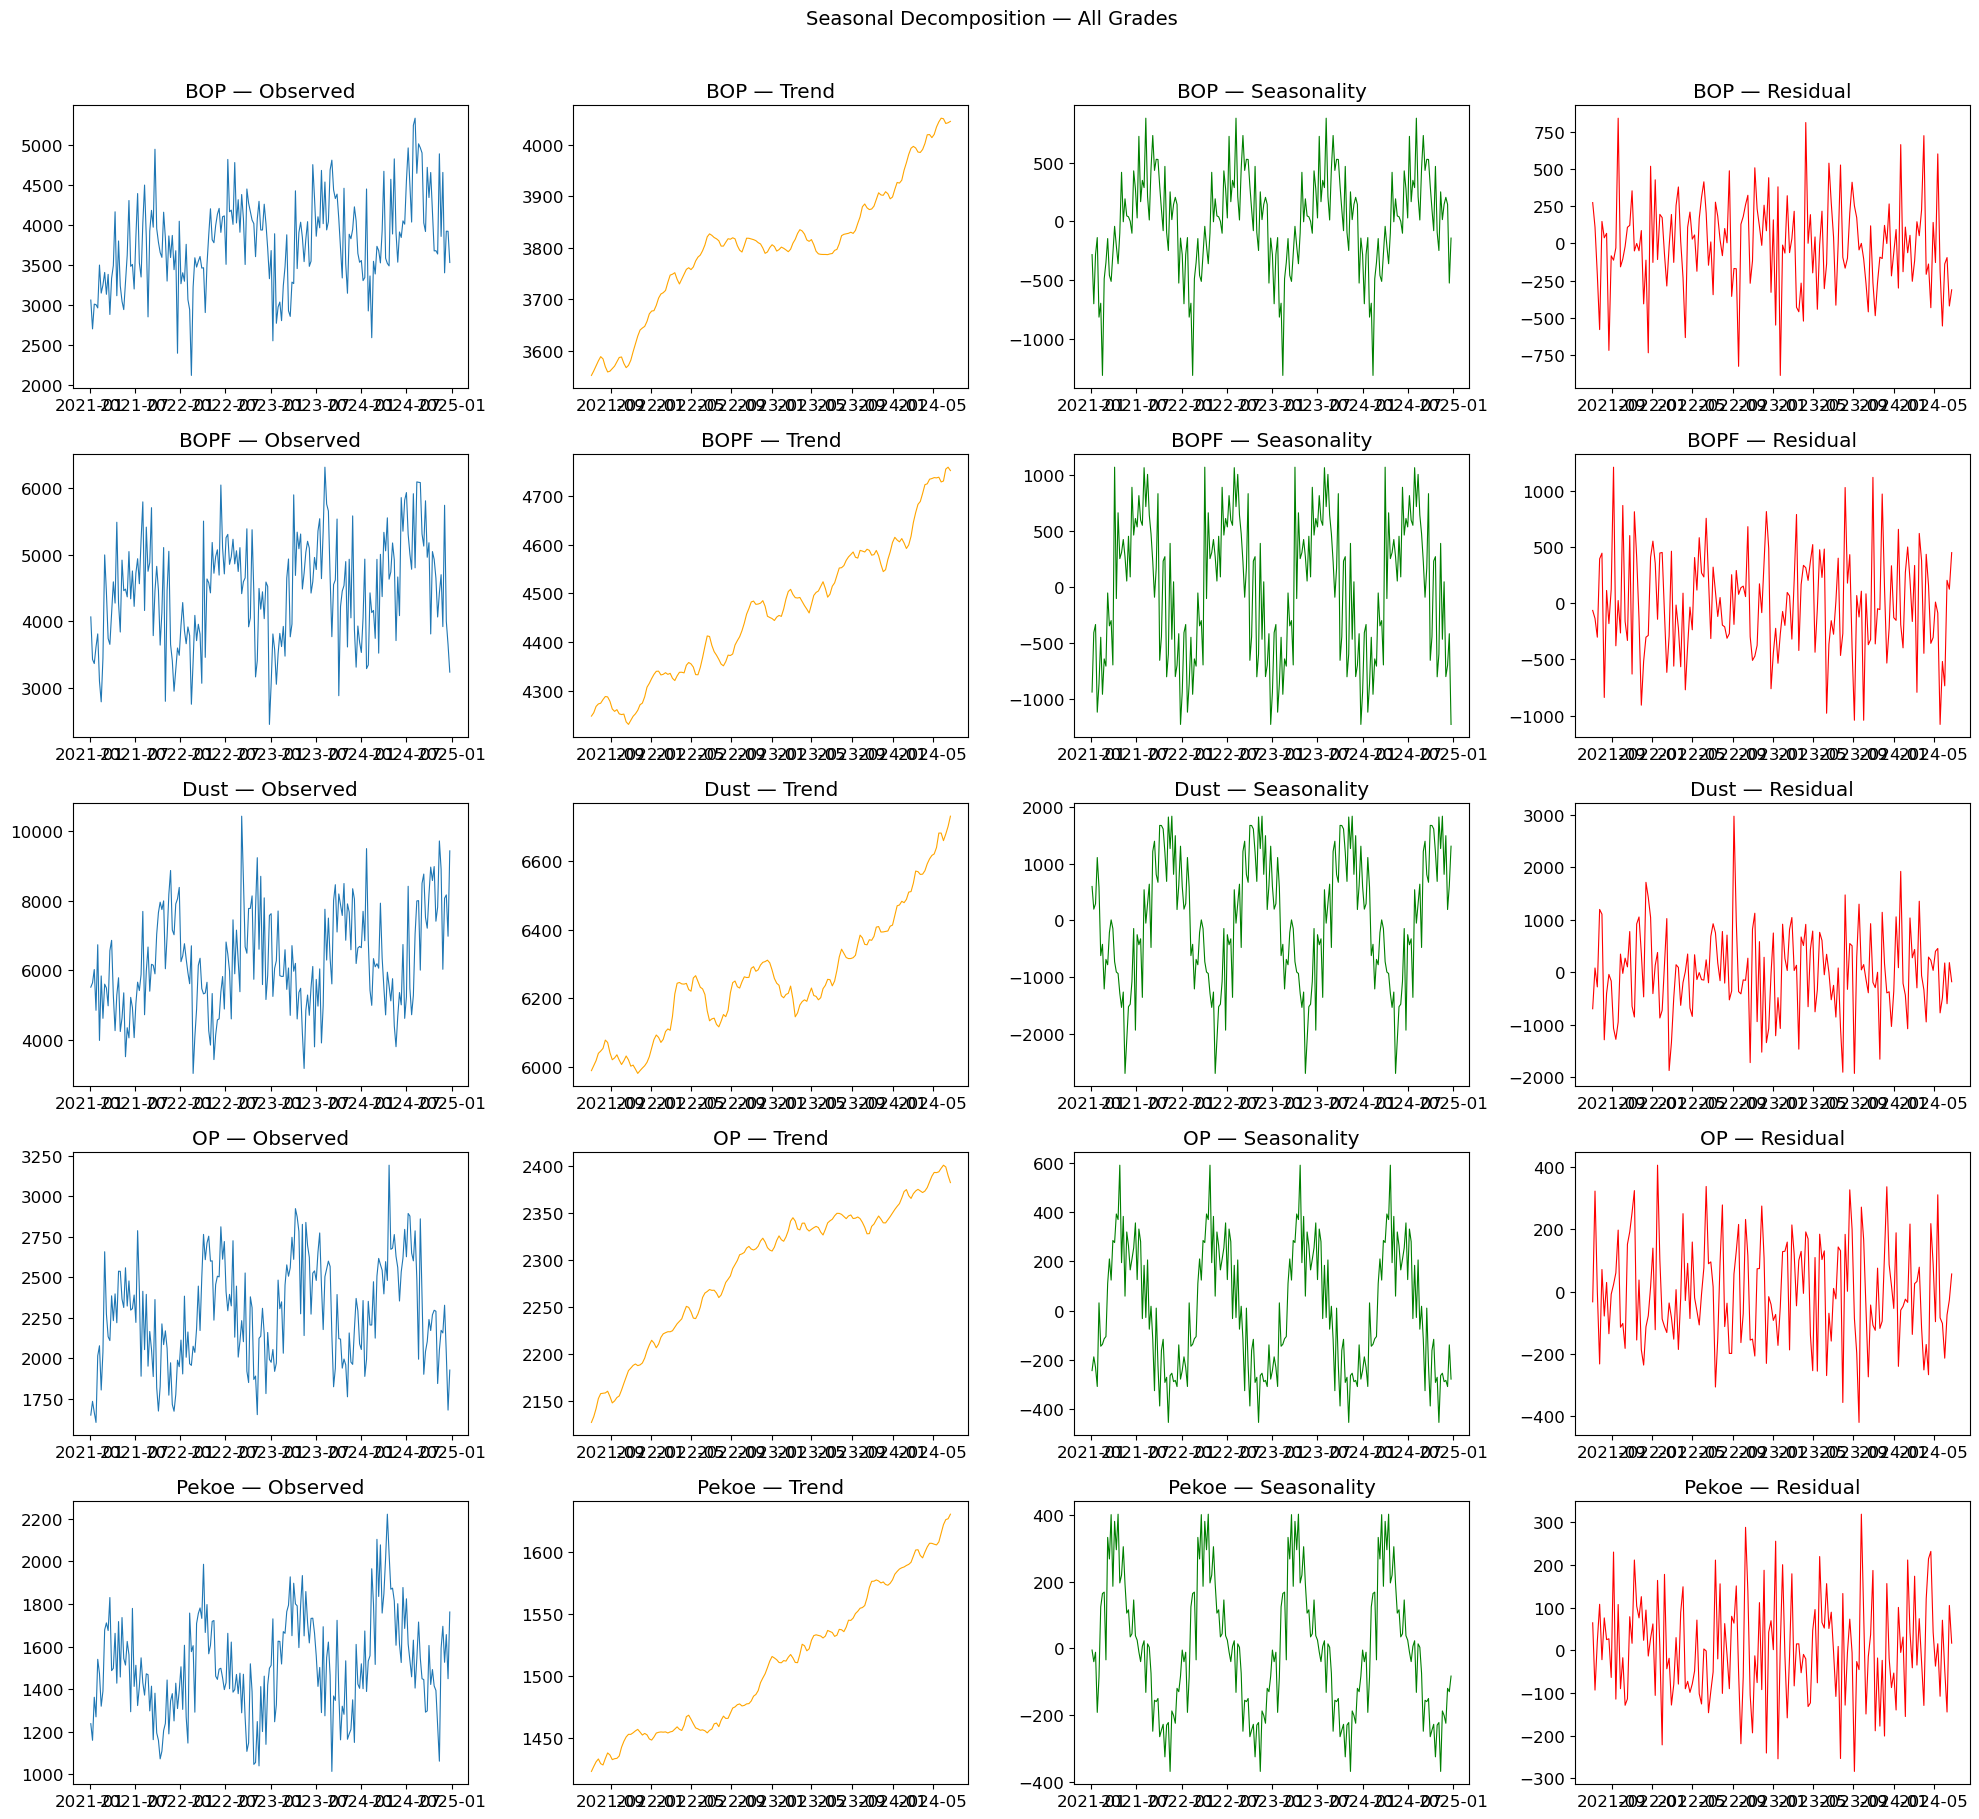

Saved to plots/seasonal_decomposition_all.png


In [15]:
fig, big_axes = plt.subplots(len(grades), 4, figsize=(20, 18))

for row, grade in enumerate(grades):
    series = df[df['grade'] == grade].set_index('week_start_date')['demand_kg']
    result = seasonal_decompose(series, model='additive', period=52)
    
    big_axes[row, 0].plot(result.observed, linewidth=0.8)
    big_axes[row, 0].set_title(f'{grade} — Observed')
    
    big_axes[row, 1].plot(result.trend, linewidth=0.8, color='orange')
    big_axes[row, 1].set_title(f'{grade} — Trend')
    
    big_axes[row, 2].plot(result.seasonal, linewidth=0.8, color='green')
    big_axes[row, 2].set_title(f'{grade} — Seasonality')
    
    big_axes[row, 3].plot(result.resid, linewidth=0.8, color='red')
    big_axes[row, 3].set_title(f'{grade} — Residual')

plt.suptitle('Seasonal Decomposition — All Grades', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/seasonal_decomposition_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/seasonal_decomposition_all.png")

In [16]:
def stationarity_test(series, name):
    print(f"\n--- {name} ---")
    
    # ADF Test (H0: non-stationary)
    adf_stat, adf_p, _, _, _, _ = adfuller(series.dropna())
    print(f"ADF p-value: {adf_p:.4f} → {'STATIONARY ✓' if adf_p < 0.05 else 'NON-STATIONARY ✗'}")
    
    # KPSS Test (H0: stationary)
    kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"KPSS p-value: {kpss_p:.4f} → {'STATIONARY ✓' if kpss_p > 0.05 else 'NON-STATIONARY ✗'}")

for grade in grades:
    series = df[df['grade'] == grade].set_index('week_start_date')['demand_kg']
    stationarity_test(series, grade)


--- BOP ---
ADF p-value: 0.0055 → STATIONARY ✓
KPSS p-value: 0.0144 → NON-STATIONARY ✗

--- BOPF ---
ADF p-value: 0.0129 → STATIONARY ✓
KPSS p-value: 0.0948 → STATIONARY ✓

--- Dust ---
ADF p-value: 0.0029 → STATIONARY ✓
KPSS p-value: 0.0796 → STATIONARY ✓

--- OP ---
ADF p-value: 0.0352 → STATIONARY ✓
KPSS p-value: 0.1000 → STATIONARY ✓

--- Pekoe ---
ADF p-value: 0.0037 → STATIONARY ✓
KPSS p-value: 0.1000 → STATIONARY ✓


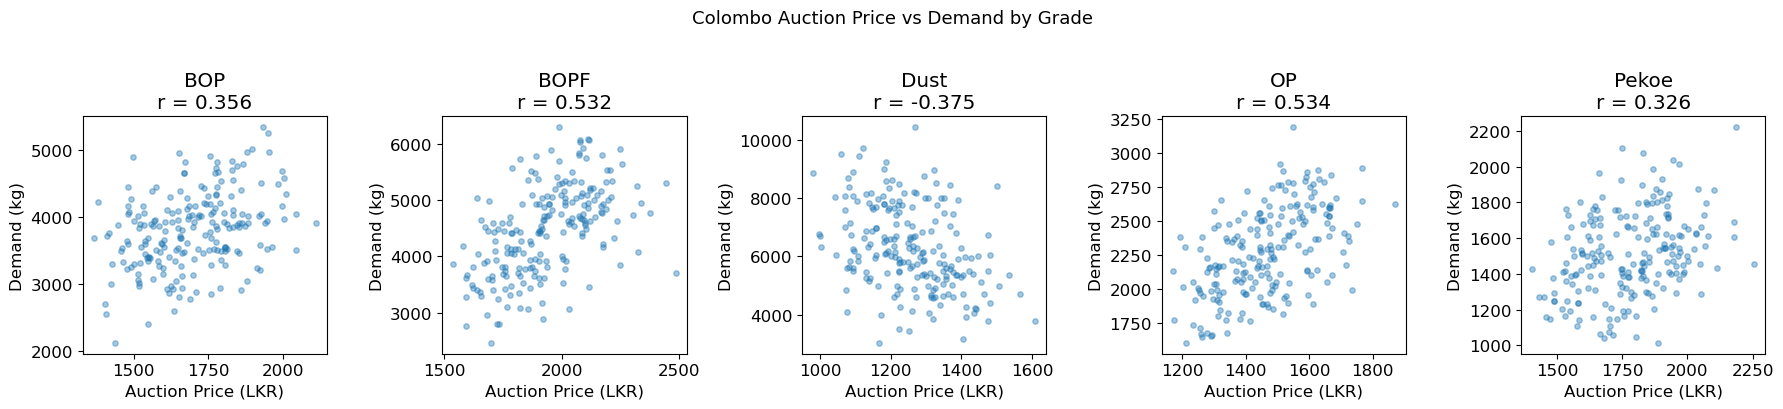

Saved to plots/price_demand_correlation.png


In [17]:
fig, axes = plt.subplots(1, len(grades), figsize=(18, 4))

for ax, grade in zip(axes, grades):
    sub = df[df['grade'] == grade]
    ax.scatter(sub['colombo_auction_price_lkr'], sub['demand_kg'], alpha=0.4, s=15)
    corr = sub['colombo_auction_price_lkr'].corr(sub['demand_kg'])
    ax.set_title(f'{grade}\nr = {corr:.3f}')
    ax.set_xlabel('Auction Price (LKR)')
    ax.set_ylabel('Demand (kg)')

plt.suptitle('Colombo Auction Price vs Demand by Grade', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/price_demand_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/price_demand_correlation.png")